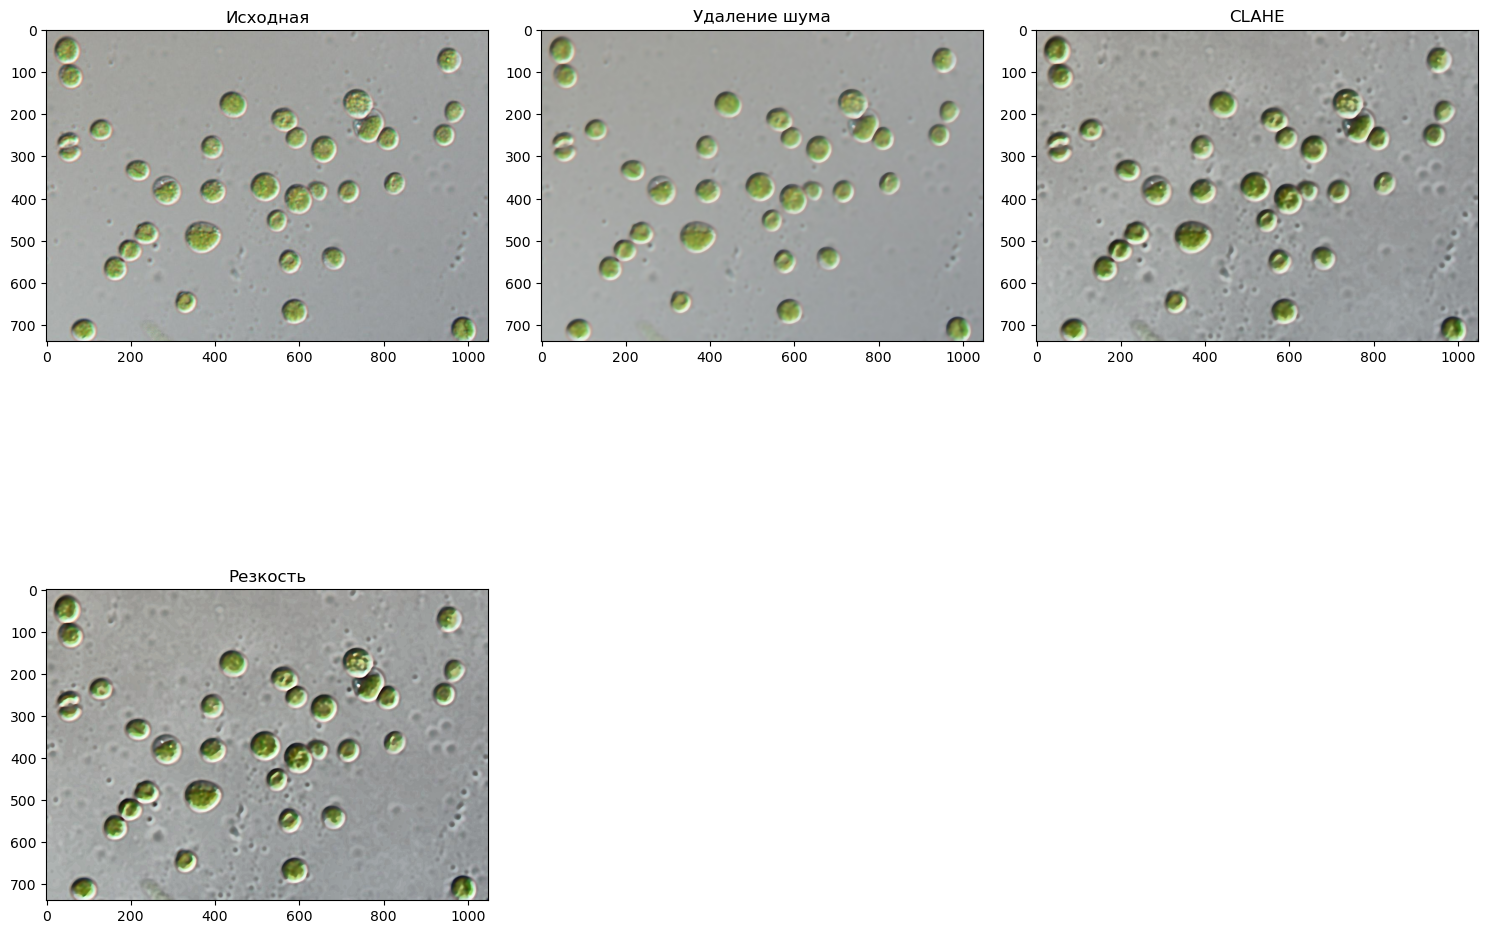

In [3]:
import sys
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np


img = cv.imread('chlorella.png')
rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

denoise_median = cv.medianBlur(img, 5)

denoise = cv.bilateralFilter(denoise_median, d=9, sigmaColor=75, sigmaSpace=75)

lab = cv.cvtColor(denoise, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)

clahe = cv.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
l2 = clahe.apply(l)

lab2 = cv.merge((l2, a, b))
bright = cv.cvtColor(lab2, cv.COLOR_LAB2BGR)

blur = cv.GaussianBlur(bright, (0, 0), 3)
sharp = cv.addWeighted(bright, 1.6, blur, -0.6, 0)




plt.figure(figsize=(15, 12))

plt.subplot(2, 3, 1), plt.imshow(rgb), plt.title("Исходная")
plt.subplot(2, 3, 2), plt.imshow(cv.cvtColor(denoise, cv.COLOR_BGR2RGB)), plt.title("Удаление шума")
plt.subplot(2, 3, 3), plt.imshow(cv.cvtColor(bright, cv.COLOR_BGR2RGB)), plt.title("CLAHE")
plt.subplot(2, 3, 4), plt.imshow(cv.cvtColor(sharp, cv.COLOR_BGR2RGB)), plt.title("Резкость")
plt.tight_layout()
plt.show()